In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding='latin1')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.info


<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
sales_by_category = df.groupby('Category')['Sales'].sum()

In [13]:
sales_by_category

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

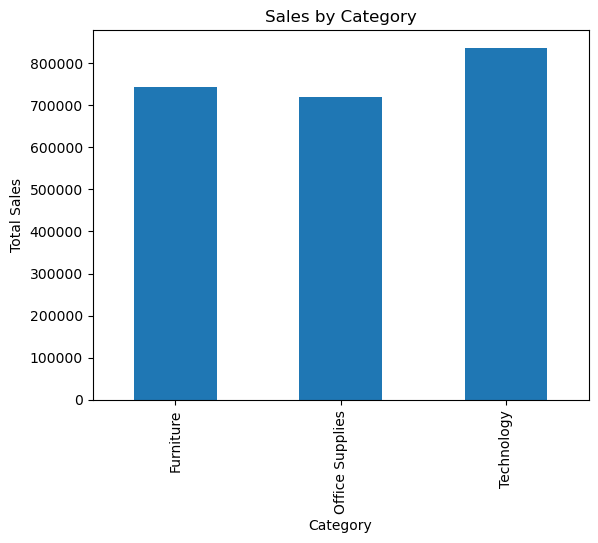

In [15]:
sales_by_category.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

In [16]:
sales_by_region = df.groupby('Region')['Sales'].sum()

In [17]:
sales_by_region

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

Text(0, 0.5, 'Total Sales')

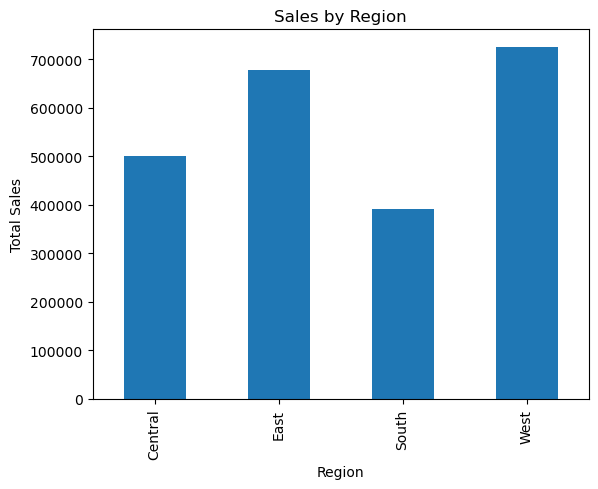

In [19]:
sales_by_region.plot(kind = 'bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

In [82]:
df['Month'] = df['Order Date'].dt.month_name()

In [83]:
df[['Order Date', 'Month']].head()

,Order Date,Month
0,2016-11-08,November
1,2016-11-08,November
2,2016-06-12,June
3,2015-10-11,October
4,2015-10-11,October


In [84]:
monthly_sales = df.groupby('Month')['Sales'].sum()

In [85]:
monthly_sales

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12.]),
 [Text(-2.0, 0, 'October'),
  Text(0.0, 0, 'April'),
  Text(2.0, 0, 'December'),
  Text(4.0, 0, 'January'),
  Text(6.0, 0, 'June'),
  Text(8.0, 0, 'May'),
  Text(10.0, 0, 'October'),
  Text(12.0, 0, '')])

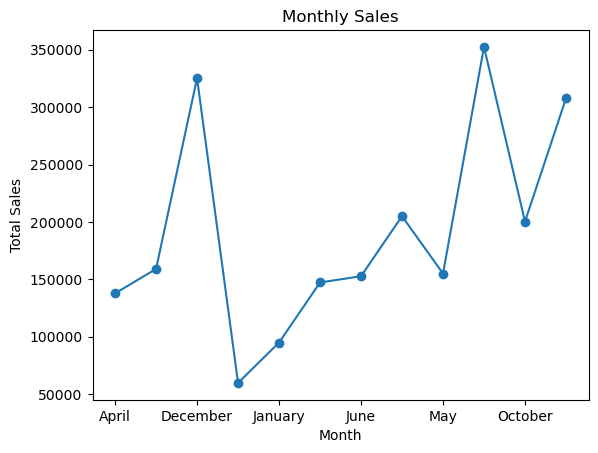

In [86]:
monthly_sales.plot(kind = 'line', marker = 'o')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation = 360)

In [90]:
top_customers = df.groupby('Customer Name')['Sales'].sum()

In [91]:
top_customers

Customer Name
Aaron Bergman          886.156
Aaron Hawkins         1744.700
Aaron Smayling        3050.692
Adam Bellavance       7755.620
Adam Hart             3250.337
                        ...   
Xylona Preis          2374.658
Yana Sorensen         6720.444
Yoseph Carroll        5454.350
Zuschuss Carroll      8025.707
Zuschuss Donatelli    1493.944
Name: Sales, Length: 793, dtype: float64

In [92]:
top_customers = top_customers.sort_values(ascending = False)

In [93]:
top_customers

Customer Name
Sean Miller        25043.050
Tamara Chand       19052.218
Raymond Buch       15117.339
Tom Ashbrook       14595.620
Adrian Barton      14473.571
                     ...    
Roy Skaria            22.328
Mitch Gastineau       16.739
Carl Jackson          16.520
Lela Donovan           5.304
Thais Sissman          4.833
Name: Sales, Length: 793, dtype: float64

In [94]:
top_10_customers = top_customers.head(10)

In [95]:
top_10_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Sean Miller'),
  Text(1, 0, 'Tamara Chand'),
  Text(2, 0, 'Raymond Buch'),
  Text(3, 0, 'Tom Ashbrook'),
  Text(4, 0, 'Adrian Barton'),
  Text(5, 0, 'Ken Lonsdale'),
  Text(6, 0, 'Sanjit Chand'),
  Text(7, 0, 'Hunter Lopez'),
  Text(8, 0, 'Sanjit Engle'),
  Text(9, 0, 'Christopher Conant')])

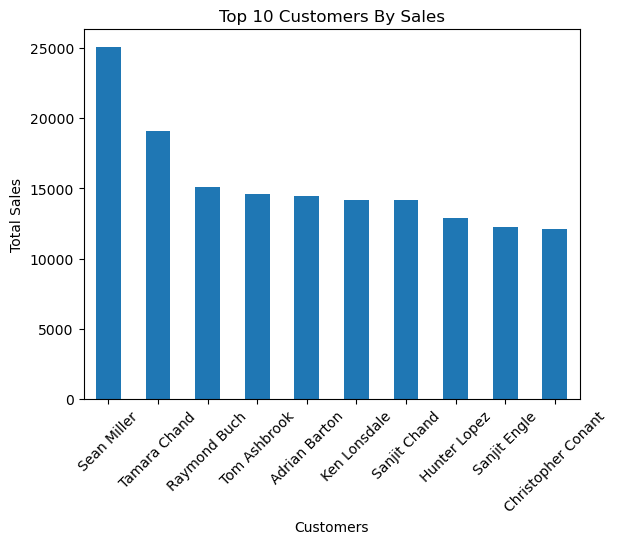

In [96]:
top_10_customers.plot(kind = 'bar')
plt.title('Top 10 Customers By Sales')
plt.xlabel('Customers')
plt.ylabel('Total Sales')

plt.xticks(rotation = 45)

In [97]:
correlation = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()

In [98]:
correlation

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

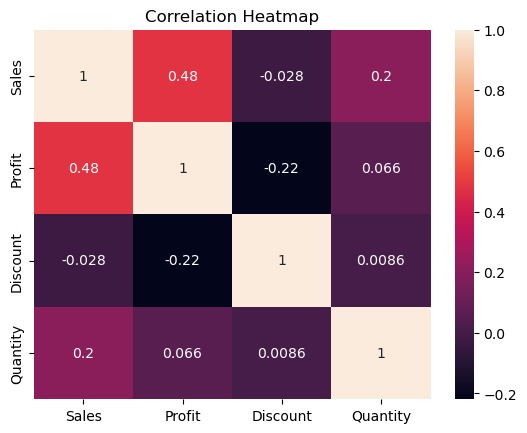

In [99]:
sns.heatmap(correlation, annot = True)
plt.title('Correlation Heatmap')

In [100]:
# 1. Sales and Profit have moderate positive correlation (0.48).

# 2. Discounts negatively affect Profit (-0.22).

# 3. Discounts do not significantly increase Sales.

# 4. Quantity has weak correlation with Profit.

In [101]:
df.to_csv('../data/cleaned/cleaned_superstore.csv', index=False)